# Day 4 — Deep Learning Engineering

## Note 4.2 — Experiments You Can Reproduce

### How to read this note

This note answers one question:

> **If I report a number today, can anybody get that same number again tomorrow?**

On Day 3 you ran experiments and read the scores. Nothing recorded how those scores were produced. If somebody asked you next month to rerun one of them, you would be guessing at the settings.

A result nobody can reproduce is a story, not a measurement. This note turns the Day 3 training loop into something that leaves a trail: it takes its settings from a recipe you can read, it writes down what produced each number, it can stop in the middle and continue without changing anything, and it says how much two runs differ when nothing at all has changed.

Everything is built in the notebook. Nothing is imported from a file you cannot see.

### Learning goal and outcome

**Goal:** be able to hand somebody a results file and have them reproduce your number exactly — or tell you precisely why they cannot.

The shape of the work:

```text
settings (a recipe)
     ↓
training run  ────────────► result: the score
     │                          +
     │                      the record: seed, settings, data, code, versions
     ↓
checkpoint (so it can be resumed)
```

**Outcome:** by the end of this note you should be able to:

- say which of three different things somebody means by "reproducible";
- seed every random number generator a run touches, and name what seeds cannot control;
- drive a run from a settings file rather than by editing code;
- save a checkpoint that resumes a run without changing a single number;
- record what produced a result: settings, data, code version, software versions;
- measure how much two runs differ when nothing changed, which is the number you need before you can claim any improvement.

### Objectives

By the end of this note you should be able to:

- explain what a random number generator is seeded for, and why seeding once at the top of a notebook is not enough;
- write a training function whose settings all come from one dictionary;
- turn that dictionary into a short text file and load it back;
- compute a **hash** of the settings, and say what it is for;
- explain what an optimizer keeps between steps, and why a checkpoint without it cannot resume;
- measure **seed noise** and **split noise** separately, and say which is larger;
- write an experiment record that answers five fixed questions;
- log the same runs into MLflow, and say what a tracking tool does and does not give you.

### Dataset used

**UCI Bank Marketing**, the same file as Note 4.1 and the same one you have used since Day 2. It downloads from UCI with no account needed. `duration` is dropped for the reason 4.1 gave: you only know a call's length after the call has ended, so it is information from the future.

The model is also unchanged from Day 3: a small neural network, 50 inputs → 64 → 32 → 1. That is deliberate. If the model and data stay the same as Day 3, then every difference you see in this note comes from the machinery around them, which is what the note is about.

### Table of contents

1. [Three different meanings of "reproducible"](#s1)
2. [Seeds, and what they cannot fix](#s2)
3. [Setting up the data](#s3)
4. [One function that runs an experiment](#s4)
5. [Settings as a recipe you can read](#s5)
6. [What a run should record about itself](#s6)
7. [Checkpoints that truly resume](#s7)
8. [How much do two runs differ when nothing changed?](#s8)
9. [The experiment record](#s9)
10. [The same runs in MLflow](#s10)
11. [Lab: reproduce a run from its record](#s11)

### Runtime budget

| Section | Approximate time |
|---|---|
| Downloading the data (first run only) | 20–60 s |
| Sections 1–3 | under 10 s |
| Section 4 — one 30-epoch run | ~10 s |
| Section 7 — four runs for the checkpoint tests | ~35 s |
| Section 8 — ten runs | ~90 s |
| Sections 9–11 | ~20 s |

About **three minutes** in total after the download. Everything is on CPU on purpose: bit-for-bit repeatability is easiest to show there, and every reader gets the same numbers.

### Environment setup

In [1]:
# pip install torch==2.14.0 scikit-learn==1.8.0 numpy==2.4.4 pandas==3.0.2 \
#             matplotlib==3.10.8 pyyaml==6.0.3 mlflow==3.16.0

import copy
import hashlib
import io
import json
import os
import platform
import random
import shutil
import subprocess
import time
import urllib.request
import uuid
import zipfile
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import yaml

pd.set_option("display.width", 150)
pd.set_option("display.max_columns", 25)

print("torch  ", torch.__version__)
print("numpy  ", np.__version__)
print("pandas ", pd.__version__)
print("pyyaml ", yaml.__version__)

torch   2.14.0+cpu
numpy   2.4.4
pandas  3.0.2
pyyaml  6.0.3


In [2]:
if torch.cuda.is_available():
    DEVICE, ACCELERATOR = torch.device("cuda"), torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    DEVICE, ACCELERATOR = torch.device("mps"), "Apple Silicon GPU (MPS)"
else:
    DEVICE, ACCELERATOR = torch.device("cpu"), "none"

# This note runs on CPU even when a GPU is present. GPU maths can differ slightly from
# run to run, and this note is about getting *identical* numbers, so CPU is the honest
# place to demonstrate it.
RUN_DEVICE = "cpu"
print(f"accelerator found : {ACCELERATOR}")
print(f"this note runs on : {RUN_DEVICE}")

accelerator found : none
this note runs on : cpu


<a id="s1"></a>
## 1. Three different meanings of "reproducible"

People use one word for three different things. Keep them apart, because each one fails for its own reasons.

**Level 1 — repeatable.** Same code, same data, same machine, same software. Run it twice, get identical numbers, to the last decimal. If this fails, something in your run is out of your control and nothing built on it can be trusted.

**Level 2 — portable.** Same code and data, a different machine or a different software version. Numbers that are *close*, but usually not identical to the last decimal. Level 2 is not about forcing them to match; it is about recording enough that the difference can be explained.

**Level 3 — robust.** Same method, different random choices: another seed, another split of the rows. The numbers move. The question is whether your **conclusion** survives the movement. A finding that only holds for one seed is not a finding.

You have already met Level 3 without the name. Day 2 and Note 3.1 report a best validation AUC of **0.7965**. That came from a split with 80% training and 20% validation, trained with the Adam optimizer. Note 3.4 used a different arrangement: 80% training, 10% validation, 10% test, with AdamW. Same model, same data, same learning rate. Section 4 below will show 0.7871.

Neither number is wrong. They were measured on different rows. A score means nothing without the recipe that produced it, and this note is about writing the recipe down.

<div align="center">

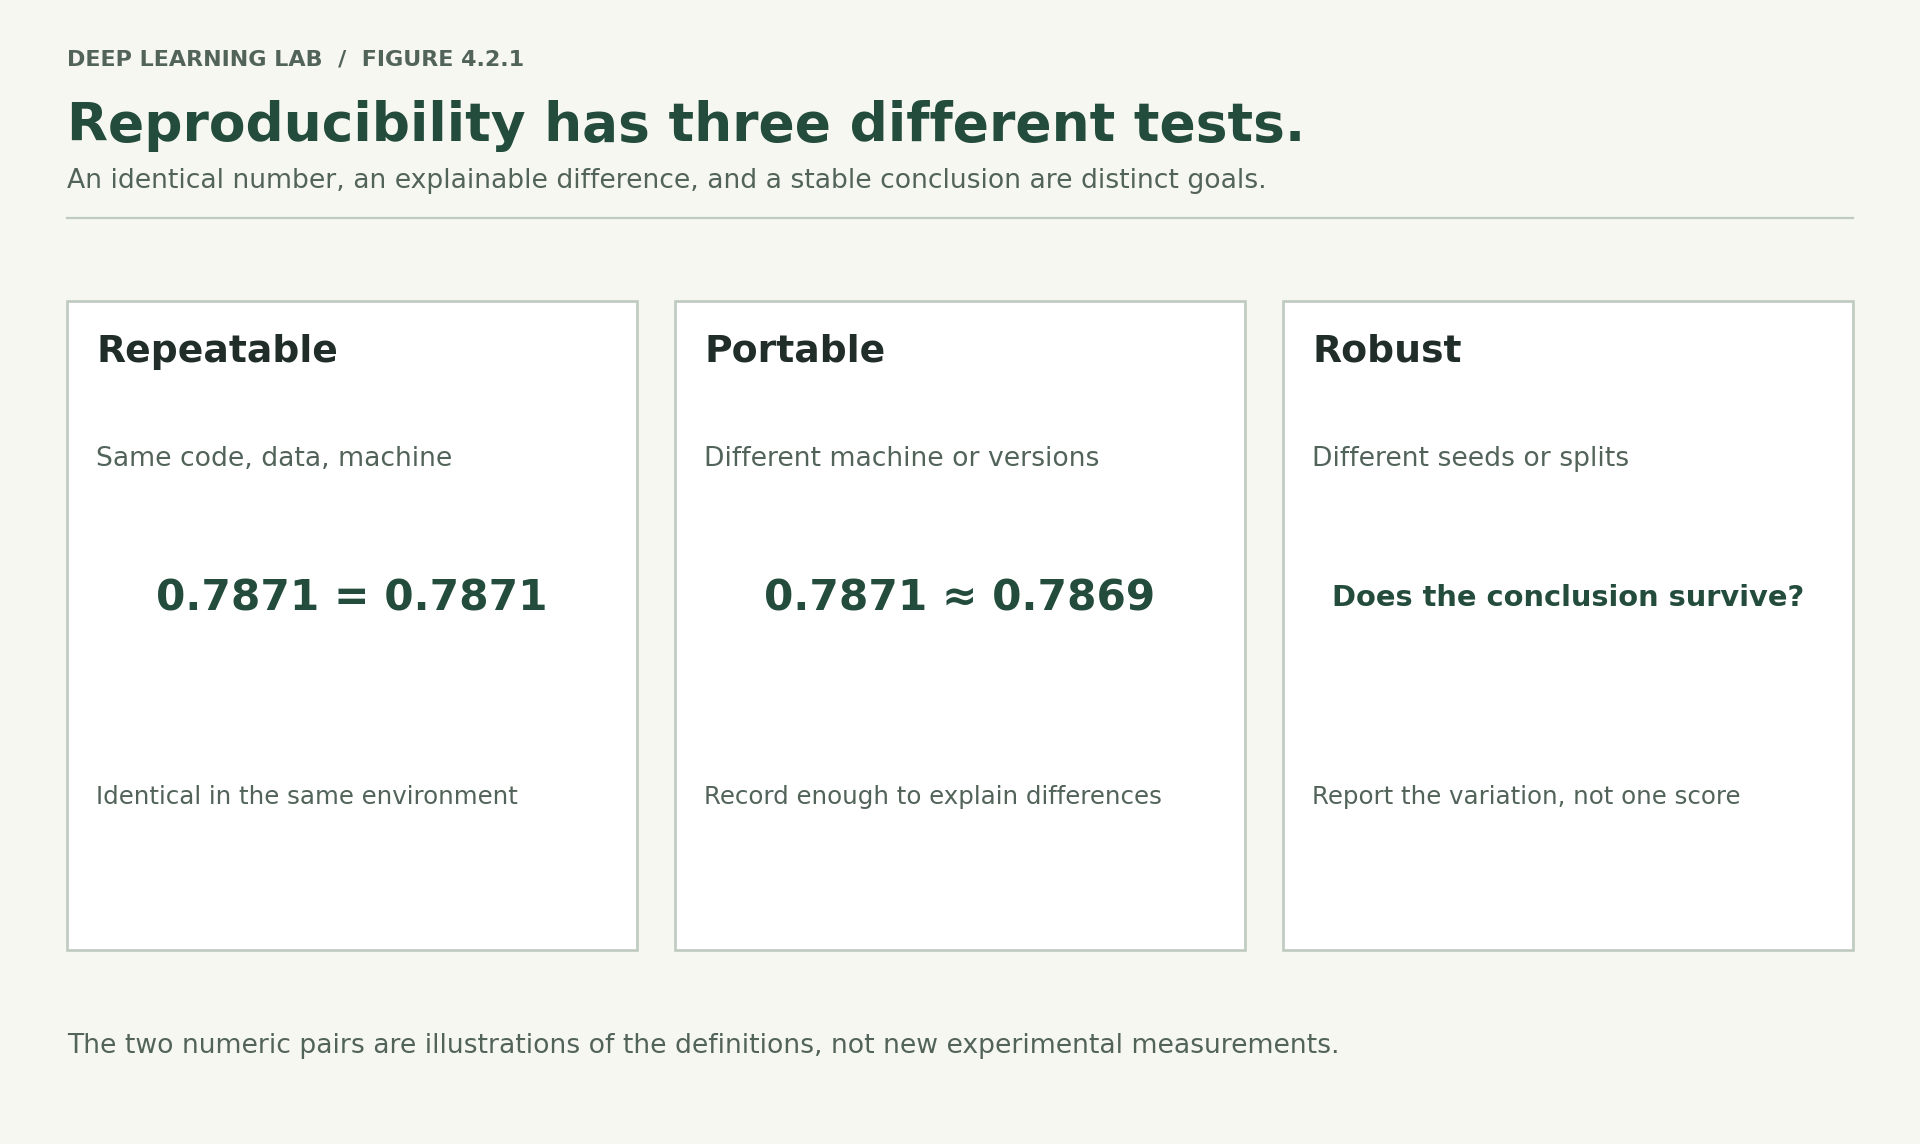

<p><b>Figure 4.2.1.</b> Repeatability, portability and robustness ask different questions. The numeric pairs illustrate definitions; actual noise estimates appear in the lesson’s experiments.</p>

</div>

**Questions to sit with**

1. A colleague reruns your code and gets 0.7869 where you got 0.7871. Which level is this, and what would you check first?
2. Which of the three levels does a noise floor measure?

<a id="s2"></a>
## 2. Seeds, and what they cannot fix

A training run makes several random choices:

- the starting values of the weights;
- the order the training rows are visited in;
- which units dropout switches off, if you use dropout;
- sometimes which rows go into which part of the split.

Those choices come from a **random number generator**, which is not really random. It is a machine that produces a fixed sequence of numbers that merely look random. Tell it where in the sequence to start — that is the **seed** — and it produces the same numbers every time.

The awkward part is that Python, NumPy and PyTorch each keep their own generator. Seeding one does not seed the others. So we write one function that seeds all of them.

Two lines in it need a word of explanation:

- `torch.use_deterministic_algorithms(True, warn_only=True)` asks PyTorch to prefer operations that give the same answer every time. Some fast GPU operations do not. `warn_only=True` means that if no repeatable version of an operation exists, PyTorch warns instead of stopping.
- `os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")` is a setting some NVIDIA maths routines need before they will behave repeatably. It does nothing on CPU, and it is harmless to set anyway.

In [3]:
def seed_everything(seed=42, deterministic=True):
    """Seed every random number generator this project touches."""
    random.seed(seed)                       # Python's own generator
    np.random.seed(seed)                    # NumPy's
    torch.manual_seed(seed)                 # PyTorch's, on CPU
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)    # PyTorch's, on every GPU
    if deterministic:
        os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")
        torch.use_deterministic_algorithms(True, warn_only=True)
        torch.backends.cudnn.benchmark = False
    return seed

seed_everything(42)
print("first three random numbers after seeding with 42:", torch.rand(3).tolist())
seed_everything(42)
print("seeded with 42 again                            :", torch.rand(3).tolist())
seed_everything(7)
print("seeded with 7                                   :", torch.rand(3).tolist())

first three random numbers after seeding with 42: [0.8822692632675171, 0.9150039553642273, 0.38286375999450684]
seeded with 42 again                            : [0.8822692632675171, 0.9150039553642273, 0.38286375999450684]
seeded with 7                                   : [0.5349225401878357, 0.19880318641662598, 0.6592116951942444]


Same seed, same numbers. Different seed, different numbers. That is the whole mechanism.

Now the bug that makes notebooks unreproducible. It is not that people forget to seed. It is that they seed **once, at the top**, and then run cells more than once.

In [4]:
seed_everything(42)
print("first call after seeding :", torch.rand(3).tolist())
print("second call, no re-seed  :", torch.rand(3).tolist())
print("third call, no re-seed   :", torch.rand(3).tolist())

first call after seeding : [0.8822692632675171, 0.9150039553642273, 0.38286375999450684]
second call, no re-seed  : [0.9593056440353394, 0.3904482126235962, 0.600895345211029]
third call, no re-seed   : [0.2565724849700928, 0.7936413288116455, 0.9407714605331421]


Each call continues further along the sequence. So the numbers a cell gets depend on **everything that ran before it**. Run a cell twice, add a cell above it, run the notebook out of order, and every later result changes.

The fix is the rule the training function in Section 4 follows: **seed at the start of every run**, not once per notebook.

There is a second half to the fix. The DataLoader shuffles the training rows each epoch, and by default it draws from the same shared PyTorch generator. So the row order also depends on everything that ran before. You can give a DataLoader its own private generator, and then its shuffling depends on nothing else at all.

In [5]:
small_dataset = torch.utils.data.TensorDataset(torch.arange(10).float().unsqueeze(1))

def first_batch(generator=None):
    loader = torch.utils.data.DataLoader(small_dataset, batch_size=5, shuffle=True, generator=generator)
    return next(iter(loader))[0].ravel().tolist()

torch.manual_seed(0)
print("shared generator, first call :", first_batch())
print("shared generator, second call:", first_batch())

print("private generator, first call :", first_batch(torch.Generator().manual_seed(0)))
print("private generator, second call:", first_batch(torch.Generator().manual_seed(0)))

shared generator, first call : [6.0, 7.0, 1.0, 4.0, 2.0]
shared generator, second call: [2.0, 4.0, 7.0, 0.0, 8.0]
private generator, first call : [3.0, 7.0, 5.0, 2.0, 0.0]
private generator, second call: [3.0, 7.0, 5.0, 2.0, 0.0]


With the shared generator the two calls differ. With a private generator seeded to 0 they are identical, no matter what else has run. Every DataLoader from here on gets its own.

### What seeds cannot control

- **The number of threads, and the hardware.** Maths libraries split work across CPU cores and add the pieces up in whatever order they finish. Adding floating-point numbers in a different order can change the last few digits.
- **Library versions.** A new PyTorch release can change how an operation is computed.
- **Some GPU operations**, which are fast precisely because they do not guarantee an order.
- **Anything outside the process**: a data file that changed, a download that returned a new version.

None of these can be seeded away. They are Level 2 problems, and the answer is to record them, which Section 6 does.

**Questions to sit with**

1. Why does giving the DataLoader its own generator make a run more repeatable than one seed at the top of the notebook?
2. You restart the kernel and run everything top to bottom, twice. Will the second and third `torch.rand(3)` calls above agree between the two passes? Why?

<a id="s3"></a>
## 3. Setting up the data

This is Note 4.1's work, compressed into three cells so this notebook stands on its own. If a step here is unfamiliar, 4.1 explains each one at length.

What the three cells do:

1. download `bank-full.csv` if it is not already here, and drop `duration`;
2. cut the rows into training, validation and test, keeping the share of yes answers the same in each part (**stratified**);
3. fit the scaler and one-hot encoder on the **training rows only**, then transform all three parts with that same fitted object.

In [6]:
BANK_URL = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
BANK_CSV = "data/bank-full.csv"

def load_bank_marketing(path=BANK_CSV):
    """Download the file if needed, then return the inputs X and the label y."""
    if not os.path.exists(path):
        raw_bytes = urllib.request.urlopen(BANK_URL, timeout=120).read()
        outer = zipfile.ZipFile(io.BytesIO(raw_bytes))
        inner = zipfile.ZipFile(io.BytesIO(outer.read("bank.zip")))
        os.makedirs(os.path.dirname(path), exist_ok=True)
        with open(path, "wb") as f:
            f.write(inner.read("bank-full.csv"))
    df = pd.read_csv(path, sep=";")
    y = (df["y"] == "yes").astype(np.float32).to_numpy()
    X = df.drop(columns=["y", "duration"])      # duration is known only after the call
    return X, y

X, y = load_bank_marketing()
print("inputs:", X.shape, "| labels:", y.shape, "| share who said yes:", round(float(y.mean()), 4))

inputs: (45211, 15) | labels: (45211,) | share who said yes: 0.117


In [7]:
from sklearn.model_selection import train_test_split

def make_split(y, policy="stratified", fractions=(0.8, 0.1, 0.1), seed=42):
    """Return {'train', 'val', 'test'} -> row numbers."""
    f_train, f_val, f_test = fractions
    rows = np.arange(len(y))
    test_share_of_rest = f_test / (f_val + f_test)

    if policy == "chronological":          # the deployment check from Note 4.1
        a, b = int(round(f_train * len(y))), int(round((f_train + f_val) * len(y)))
        return {"train": rows[:a], "val": rows[a:b], "test": rows[b:]}

    stratify_on = y if policy == "stratified" else None
    train, rest = train_test_split(rows, train_size=f_train, random_state=seed, stratify=stratify_on)
    stratify_rest = y[rest] if policy == "stratified" else None
    val, test = train_test_split(rest, test_size=test_share_of_rest, random_state=seed, stratify=stratify_rest)
    return {"train": train, "val": val, "test": test}

split = make_split(y, "stratified", seed=42)
for part, rows in split.items():
    print(f"{part:<6} {len(rows):>6} rows | share who said yes {y[rows].mean():.4f}")

train   36168 rows | share who said yes 0.1170
val      4521 rows | share who said yes 0.1170
test     4522 rows | share who said yes 0.1170


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def build_preprocessor(X):
    """Scale the numeric columns, one-hot the categorical ones."""
    numeric = X.select_dtypes(include="number").columns.tolist()
    categorical = [c for c in X.columns if c not in numeric]
    return ColumnTransformer([
        ("scale_numbers", StandardScaler(), numeric),
        ("one_hot_categories", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical),
    ])

def prepare_arrays(X, y, split):
    """Fit on the training rows, transform every part, return plain float32 arrays."""
    pre = build_preprocessor(X).fit(X.iloc[split["train"]])
    inputs = {part: pre.transform(X.iloc[rows]).astype(np.float32) for part, rows in split.items()}
    labels = {part: y[rows] for part, rows in split.items()}
    return inputs, labels, pre

inputs, labels, preprocessor = prepare_arrays(X, y, split)
print("model inputs per row:", inputs["train"].shape[1])
print({part: array.shape for part, array in inputs.items()})

model inputs per row: 50
{'train': (36168, 50), 'val': (4521, 50), 'test': (4522, 50)}


<a id="s4"></a>
## 4. One function that runs an experiment

Day 3 wrote a training loop in a cell and edited it whenever something needed changing. That works once. It stops working when you want twenty runs that differ in one setting, because now you cannot tell which version of the cell produced which number.

The fix is a function whose every setting arrives in one dictionary. Then the settings *are* the experiment, and they can be saved, compared and hashed.

Build it in pieces first, then assemble.

### The model

Three linear layers with ReLU between them, exactly the Day 2 and Day 3 model. `nn.Sequential` just runs the layers in order.

Note the `torch.manual_seed` at the top: the starting weights are random, so the model has to be built at a known point in the sequence for the run to be repeatable.

In [9]:
def build_model(settings, n_inputs):
    """The Day 3 network: n_inputs -> 64 -> 32 -> 1."""
    torch.manual_seed(settings["seed"])
    layers, previous = [], n_inputs
    for width in settings["hidden"]:
        layers += [nn.Linear(previous, width), nn.ReLU()]
        if settings["dropout"] > 0:
            layers.append(nn.Dropout(settings["dropout"]))
        previous = width
    layers.append(nn.Linear(previous, 1))
    return nn.Sequential(*layers)

demo_model = build_model({"seed": 42, "hidden": (64, 32), "dropout": 0.0}, 50)
print(demo_model)
print("parameters:", sum(p.numel() for p in demo_model.parameters()))

Sequential(
  (0): Linear(in_features=50, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
)
parameters: 5377


### Scoring

After each epoch we want to know how the model is doing. `torch.no_grad()` says "do not keep the information needed for a backward pass here", which makes scoring faster and uses less memory, since we are not going to train on it.

`torch.sigmoid` turns the model's raw output into a number between 0 and 1, so it can be read as a probability.

In [10]:
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score

def score(model, X_tensor, y_array, loss_function):
    """Return the predicted probabilities and a dictionary of scores."""
    model.eval()                                   # switch off dropout etc.
    with torch.no_grad():
        logits = model(X_tensor).float()
    probabilities = torch.sigmoid(logits).numpy().ravel()
    return probabilities, {
        "loss": loss_function(logits, torch.tensor(y_array).unsqueeze(1)).item(),
        "auc": float(roc_auc_score(y_array, probabilities)),
        "pr_auc": float(average_precision_score(y_array, probabilities)),
        "accuracy": float(accuracy_score(y_array, probabilities > 0.5)),
    }

### The settings

One dictionary holds every choice. Anything you pass in replaces the matching entry; anything you leave out keeps the value below. So an experiment is described by *what it changes*, which is usually one or two things.

In [11]:
BASELINE = dict(
    name="baseline",          # what to call this run's files
    split="stratified",       # which splitting rule (Note 4.1)
    split_seed=42,            # which rows land where
    seed=42,                  # starting weights and row order
    hidden=(64, 32),          # layer widths
    dropout=0.0,
    lr=1e-3,                  # learning rate
    weight_decay=0.0,
    batch_size=256,
    epochs=30,
    pos_weight=None,          # makes the rare class count for more (Note 4.1 section 10)
    checkpoint_every=0,       # 0 means never save mid-run
    resume=False,             # continue from a saved checkpoint?
    stop_after=None,          # pretend the machine died after this epoch
)

print(json.dumps({k: str(v) for k, v in BASELINE.items()}, indent=2))

{
  "name": "baseline",
  "split": "stratified",
  "split_seed": "42",
  "seed": "42",
  "hidden": "(64, 32)",
  "dropout": "0.0",
  "lr": "0.001",
  "weight_decay": "0.0",
  "batch_size": "256",
  "epochs": "30",
  "pos_weight": "None",
  "checkpoint_every": "0",
  "resume": "False",
  "stop_after": "None"
}


### The function itself

Now the whole thing. Walking through what it does, in order:

1. **seed** everything, so the run starts from a known point;
2. **split** the rows and **prepare** the arrays, using the rules from Note 4.1;
3. **build** the model and the optimizer. AdamW is the optimizer from Day 3; it keeps two running averages per weight, which will matter in Section 7;
4. **`BCEWithLogitsLoss`** is the loss for a yes/no problem. It expects raw outputs, not probabilities, and applies the sigmoid itself, which is more numerically stable;
5. **DataLoader** with its own generator, so the row order is under our control;
6. for each **epoch**, walk the training rows in batches: clear the old gradients, run the batch forward, measure the loss, run backward, let the optimizer update the weights;
7. after each epoch, **score** the validation rows and remember the epoch if it is the best so far. `copy.deepcopy` takes a full copy of the weights, so later training does not overwrite the best ones;
8. at the end, **restore** the best epoch's weights and score the **test** rows once. Choosing the epoch on validation and reporting on test is the point of having three parts;
9. return a dictionary with the history, the scores, and the artifacts we might want afterwards.

In [12]:
def run_experiment(settings, quiet=False, results_dir="results", checkpoint_dir="checkpoints"):
    """Train once, following `settings`, and return everything about the run."""
    settings = {**BASELINE, **settings}
    settings["hidden"] = list(settings["hidden"])
    seed_everything(settings["seed"])

    split = make_split(y, settings["split"], seed=settings["split_seed"])
    inputs, labels, pre = prepare_arrays(X, y, split)
    X_train = torch.tensor(inputs["train"])
    y_train = torch.tensor(labels["train"]).unsqueeze(1)
    X_val, X_test = torch.tensor(inputs["val"]), torch.tensor(inputs["test"])

    model = build_model(settings, X_train.shape[1])
    optimizer = torch.optim.AdamW(model.parameters(), lr=settings["lr"],
                                  weight_decay=settings["weight_decay"])
    weight = None if settings["pos_weight"] is None else torch.tensor([float(settings["pos_weight"])])
    loss_function = nn.BCEWithLogitsLoss(pos_weight=weight)

    generator = torch.Generator().manual_seed(settings["seed"])
    loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(X_train, y_train),
                                         batch_size=settings["batch_size"], shuffle=True,
                                         generator=generator)

    history, best, start_epoch = [], {"auc": -1.0, "epoch": 0, "weights": None}, 1
    checkpoint_path = os.path.join(checkpoint_dir, f"{settings['name']}.pt")
    if settings["resume"] and os.path.exists(checkpoint_path):
        start_epoch, history, best = load_checkpoint(checkpoint_path, model, optimizer, generator)
        if not quiet:
            print(f"[{settings['name']}] resumed at epoch {start_epoch}")

    started = time.time()
    interrupted = False
    for epoch in range(start_epoch, settings["epochs"] + 1):
        model.train()
        running_loss, seen = 0.0, 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()                       # forget last batch's gradients
            loss = loss_function(model(batch_x), batch_y)
            loss.backward()                             # work out each weight's blame
            optimizer.step()                            # nudge the weights
            running_loss += loss.item() * len(batch_x)
            seen += len(batch_x)

        _, train_scores = score(model, X_train, labels["train"], loss_function)
        _, val_scores = score(model, X_val, labels["val"], loss_function)
        history.append({"epoch": epoch, "train_loss": running_loss / seen,
                        "val_loss": val_scores["loss"], "train_auc": train_scores["auc"],
                        "val_auc": val_scores["auc"], "val_accuracy": val_scores["accuracy"]})

        if val_scores["auc"] > best["auc"]:
            best = {"auc": val_scores["auc"], "epoch": epoch,
                    "weights": copy.deepcopy(model.state_dict())}

        if settings["checkpoint_every"] and epoch % settings["checkpoint_every"] == 0:
            save_checkpoint(checkpoint_path, model, optimizer, generator, epoch, history, best)

        if settings["stop_after"] is not None and epoch >= settings["stop_after"]:
            interrupted = True                          # pretend the machine died here
            break

    final_weights = copy.deepcopy(model.state_dict())
    model.load_state_dict(best["weights"])              # go back to the best epoch
    val_probabilities, val_scores = score(model, X_val, labels["val"], loss_function)
    test_probabilities, test_scores = score(model, X_test, labels["test"], loss_function)

    result = {
        "settings": settings,
        "run": run_record(settings, X, y, model),
        "history": history,
        "best_epoch": best["epoch"],
        "best_val_auc": best["auc"],
        "val_at_best": val_scores,
        "test": {**test_scores, "share_who_said_yes": float(labels["test"].mean()),
                 "average_prediction": float(test_probabilities.mean())},
        "seconds": time.time() - started,
        "interrupted": interrupted,
    }
    os.makedirs(results_dir, exist_ok=True)
    with open(os.path.join(results_dir, f"{settings['name']}.json"), "w") as f:
        json.dump(result, f, indent=2, default=str)

    if not quiet:
        print(f"[{settings['name']}] {result['seconds']:.1f}s | best epoch {best['epoch']} | "
              f"val AUC {best['auc']:.4f} | test AUC {test_scores['auc']:.4f}"
              f"{' | INTERRUPTED' if interrupted else ''}")

    result["artifacts"] = {"model": model, "preprocessor": pre, "split": split,
                           "final_weights": final_weights, "test_probabilities": test_probabilities}
    return result

The function refers to three helpers we have not written yet: `run_record`, `save_checkpoint` and `load_checkpoint`. Sections 6 and 7 build them. Python only looks them up when the function runs, so we define them now, in their simplest form, and replace them properly later.

In [13]:
def run_record(settings, X, y, model):
    """Placeholder. Section 6 replaces this with the real thing."""
    return {}

def save_checkpoint(path, model, optimizer, generator, epoch, history, best):
    """Placeholder. Section 7 replaces this."""
    pass

def load_checkpoint(path, model, optimizer, generator):
    """Placeholder. Section 7 replaces this."""
    return 1, [], {"auc": -1.0, "epoch": 0, "weights": None}

reference = run_experiment({"name": "reference"})
print()
print("epoch  validation AUC")
for row in reference["history"][15:20]:
    print(f"  {row['epoch']:>2}   {row['val_auc']:.4f}")

[reference] 8.5s | best epoch 18 | val AUC 0.7871 | test AUC 0.8016

epoch  validation AUC
  16   0.7845
  17   0.7846
  18   0.7871
  19   0.7849
  20   0.7837


Best epoch **18**, validation AUC **0.7871**. That is Note 3.4's number reproduced exactly: same rows, same model, same settings.

The test AUC printed beside it is new. It is the first test-set number for Bank Marketing in this course, because Day 3 only ever looked at validation. The difference matters: the validation score helped choose the epoch, so it is slightly flattered. The test score chose nothing, so it is the one to report.

And the comparison from Section 1 is now concrete: Day 2's 0.7965 came from a different split and a different optimizer. This is 0.7871. Same model, different recipe, different number.

**Questions to sit with**

1. The function scores the test rows once, after restoring the best epoch. What would go wrong if it picked the best epoch by *test* AUC instead?
2. Why is `copy.deepcopy` needed when saving the best weights, rather than just keeping a reference to `model.state_dict()`?

<a id="s5"></a>
## 5. Settings as a recipe you can read

The settings are now a Python dictionary. That is already better than editing a cell, but a dictionary lives inside the notebook. To share an experiment, or to rerun one next year, the settings need to be a **file**.

**YAML** is a plain-text format for exactly this. It is readable by a person, it can be loaded by a machine, and because it is text, git can show you what changed between two versions of it.

`yaml.safe_dump` writes a dictionary to text. `sort_keys=False` keeps our order rather than alphabetising.

In [14]:
os.makedirs("configs", exist_ok=True)

settings_for_file = {k: (list(v) if isinstance(v, tuple) else v) for k, v in BASELINE.items()}
with open("configs/baseline.yaml", "w") as f:
    yaml.safe_dump(settings_for_file, f, sort_keys=False)

print(open("configs/baseline.yaml").read())

name: baseline
split: stratified
split_seed: 42
seed: 42
hidden:
- 64
- 32
dropout: 0.0
lr: 0.001
weight_decay: 0.0
batch_size: 256
epochs: 30
pos_weight: null
checkpoint_every: 0
resume: false
stop_after: null



### A fingerprint for the settings

Twenty runs produce twenty settings files, many of them nearly identical. Comparing them by eye is slow and error-prone. A **hash** solves this.

A hash function takes any text and returns a short string of letters and numbers. The same text always gives the same string. Different text almost always gives a different one. So the hash is a fingerprint: if two runs carry the same fingerprint, they used the same settings.

`json.dumps(..., sort_keys=True)` turns the dictionary into text with the keys in a fixed order, so that writing the same settings in a different order still gives the same fingerprint. `[:12]` keeps the first twelve characters, which is short enough to read and long enough to be unique here.

In [15]:
def settings_hash(settings):
    """A short fingerprint of the settings that decide the result."""
    ignore = {"name", "resume", "stop_after", "checkpoint_every"}   # how it was run, not what was run
    to_hash = {k: v for k, v in settings.items() if k not in ignore}
    as_text = json.dumps(to_hash, sort_keys=True, default=str)
    return hashlib.sha256(as_text.encode()).hexdigest()[:12]

print("hello      ->", hashlib.sha256(b"hello").hexdigest()[:12])
print("hello!     ->", hashlib.sha256(b"hello!").hexdigest()[:12])
print()
reordered = dict(reversed(list(settings_for_file.items())))
print("baseline settings                 :", settings_hash(settings_for_file))
print("same settings, keys in reverse    :", settings_hash(reordered))
print("same settings, different run name :", settings_hash({**settings_for_file, "name": "anything"}))
print("learning rate changed to 0.0003   :", settings_hash({**settings_for_file, "lr": 0.0003}))

hello      -> 2cf24dba5fb0
hello!     -> ce06092fb948

baseline settings                 : 175eba29a158
same settings, keys in reverse    : 175eba29a158
same settings, different run name : 175eba29a158
learning rate changed to 0.0003   : 0585c21371f6


Changing one character of the input changes the fingerprint completely. Reordering the keys does not, and neither does renaming the run — because the name says how this execution was labelled, not what was computed. The learning rate does change it, because that changes the result.

### One trap worth meeting now

YAML has a rule that catches nearly everybody who writes learning rates in scientific notation.

In [16]:
print("written as 3e-4   ->", repr(yaml.safe_load("lr: 3e-4")["lr"]))
print("written as 3.0e-4 ->", repr(yaml.safe_load("lr: 3.0e-4")["lr"]))
print("written as 0.0003 ->", repr(yaml.safe_load("lr: 0.0003")["lr"]))

written as 3e-4   -> '3e-4'
written as 3.0e-4 -> 0.0003
written as 0.0003 -> 0.0003


`3e-4` comes back as the **text** `'3e-4'`, not the number 0.0003, because the YAML version PyYAML follows requires a decimal point in scientific notation. Watch what happens if that text reaches the optimizer.

In [17]:
try:
    run_experiment({"name": "broken_lr", "lr": yaml.safe_load("lr: 3e-4")["lr"]})
except TypeError as error:
    print("the optimizer refused it:", error)

the optimizer refused it: '<=' not supported between instances of 'float' and 'str'


That is the good outcome: it fails immediately and loudly. The bad outcome is code that stores or compares the value silently and leaves you wondering why two runs differ. Write `3.0e-4` or `0.0003`.

**Questions to sit with**

1. Why does the fingerprint deliberately ignore `name`, `resume`, `stop_after` and `checkpoint_every`?
2. Two runs have the same settings fingerprint but different scores. Name three things that could explain it. (Section 6 records all three.)

<a id="s6"></a>
## 6. What a run should record about itself

A score on its own cannot be checked. To make it checkable, each run records the things somebody would need to get it again:

- **a run id** — a name for this particular execution;
- **the settings fingerprint** from Section 5 — what was run;
- **a data fingerprint** — which exact rows and labels were used;
- **the code version** — which commit of your repository produced it;
- **the software versions** — the Level 2 details from Section 2.

### A fingerprint for the data

The settings fingerprint says what you asked for. It says nothing about the data, which can change without anybody noticing: a file gets re-downloaded, a colleague fixes a column, a row is appended.

So we hash the data too. `pd.util.hash_pandas_object` turns every row into a number; we hash those numbers, the column names, and the labels.

In [18]:
def data_fingerprint(X, y):
    """A short hash of the exact rows, columns and labels a run saw."""
    hasher = hashlib.sha256()
    hasher.update(pd.util.hash_pandas_object(X, index=True).to_numpy().tobytes())
    hasher.update(",".join(map(str, X.columns)).encode())
    hasher.update(np.asarray(y).tobytes())
    return hasher.hexdigest()[:12]

print("our data                    :", data_fingerprint(X, y))
print("the same data again         :", data_fingerprint(X, y))
print("with one label flipped      :", data_fingerprint(X, np.concatenate([[1 - y[0]], y[1:]])))
print("with one column dropped     :", data_fingerprint(X.drop(columns="age"), y))

our data                    : ae4909e99a00
the same data again         : ae4909e99a00
with one label flipped      : 6e3fe36d9cc2
with one column dropped     : 4fae1970b4a5


One flipped label out of 45,211 changes the fingerprint. That is what you want: it is a smoke alarm, not a summary.

### Which version of the code

If your project is in git, the commit id says exactly which code ran. Two things are worth recording: the commit, and whether the working folder had **uncommitted changes** at the time. A run from a folder with uncommitted changes came from code that exists nowhere except that machine, at that moment.

`subprocess.run` runs a command as if you had typed it in a terminal and hands back its output.

In [19]:
def git_state(folder="."):
    """Which commit produced this run, and were there uncommitted changes?"""
    try:
        commit = subprocess.run(["git", "rev-parse", "--short", "HEAD"], cwd=folder,
                                capture_output=True, text=True, check=True).stdout.strip()
        changes = subprocess.run(["git", "status", "--porcelain"], cwd=folder,
                                 capture_output=True, text=True, check=True).stdout.strip()
        return {"commit": commit, "uncommitted_changes": changes != ""}
    except (OSError, subprocess.CalledProcessError):
        return {"commit": None, "uncommitted_changes": None, "note": "not inside a git repository"}

print("this notebook's folder:", git_state())

this notebook's folder: {'commit': None, 'uncommitted_changes': None, 'note': 'not inside a git repository'}


This folder is probably not a git repository, and the function says so rather than inventing a value. To see it work, here is a small repository created, committed to, and then edited.

In [20]:
scratch = "scratch_repo"
shutil.rmtree(scratch, ignore_errors=True)
os.makedirs(scratch)

def git(*args):
    return subprocess.run(["git", *args], cwd=scratch, capture_output=True, text=True)

git("init", "-q")
git("config", "user.email", "you@example.com")
git("config", "user.name", "Learner")
with open(f"{scratch}/settings.yaml", "w") as f:
    f.write("lr: 0.001\n")
git("add", ".")
git("commit", "-q", "-m", "first settings")
print("straight after committing:", git_state(scratch))

with open(f"{scratch}/settings.yaml", "w") as f:
    f.write("lr: 0.01\n")
print("after editing the file   :", git_state(scratch))

shutil.rmtree(scratch)

straight after committing: {'commit': 'e4e5adb', 'uncommitted_changes': False}
after editing the file   : {'commit': 'e4e5adb', 'uncommitted_changes': True}


### The software versions, and the whole record

Now put it together and replace the placeholder from Section 4.

In [21]:
def environment_info():
    """The details that explain small differences between machines."""
    import sklearn
    return {"python": platform.python_version(), "platform": platform.platform(),
            "torch": torch.__version__, "numpy": np.__version__,
            "pandas": pd.__version__, "sklearn": sklearn.__version__,
            "device": RUN_DEVICE, "cpu_threads": torch.get_num_threads()}

def run_record(settings, X, y, model):
    """Everything a stranger would need to judge this result."""
    return {
        "run_id": f"{settings['name']}-{uuid.uuid4().hex[:8]}",
        "started_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "settings_hash": settings_hash(settings),
        "data_fingerprint": data_fingerprint(X, y),
        "git": git_state(),
        "environment": environment_info(),
        "n_parameters": sum(p.numel() for p in model.parameters()),
    }

reference = run_experiment({"name": "reference"})
print()
print(json.dumps(reference["run"], indent=2))

[reference] 7.9s | best epoch 18 | val AUC 0.7871 | test AUC 0.8016

{
  "run_id": "reference-019891cd",
  "started_at": "2026-09-24T17:43:26+00:00",
  "settings_hash": "175eba29a158",
  "data_fingerprint": "ae4909e99a00",
  "git": {
    "commit": null,
    "uncommitted_changes": null,
    "note": "not inside a git repository"
  },
  "environment": {
    "python": "3.12.3",
    "platform": "Linux-6.18.44-fc-v40-x86_64-with-glibc2.39",
    "torch": "2.14.0+cpu",
    "numpy": "2.4.4",
    "pandas": "3.0.2",
    "sklearn": "1.8.0",
    "device": "cpu",
    "cpu_threads": 1
  },
  "n_parameters": 5377
}


Every future run now carries this block, because `run_experiment` calls `run_record` at the end.

One more thing worth pinning: the versions for the whole project, in a file that can be installed later.

In [22]:
import importlib.metadata as metadata
import sklearn
import matplotlib

pins = {"torch": torch.__version__.split("+")[0], "scikit-learn": sklearn.__version__,
        "numpy": np.__version__, "pandas": pd.__version__,
        "matplotlib": matplotlib.__version__, "pyyaml": yaml.__version__}
with open("requirements-day4.txt", "w") as f:
    f.write("\n".join(f"{name}=={version}" for name, version in pins.items()) + "\n")

print(open("requirements-day4.txt").read())

torch==2.14.0
scikit-learn==1.8.0
numpy==2.4.4
pandas==3.0.2
matplotlib==3.10.8
pyyaml==6.0.3



**Questions to sit with**

1. Two runs share a settings fingerprint but have different data fingerprints. What happened, and which result do you trust?
2. Why record the number of CPU threads?

<a id="s7"></a>
## 7. Checkpoints that truly resume

Long runs get interrupted. A Colab session times out, a laptop sleeps, a shared machine takes your job away. A **checkpoint** is a saved copy of the run so you can continue instead of starting over.

The usual mistake is to save only the weights. That is enough to *use* the model. It is not enough to *continue training* it, and the reason is the optimizer.

AdamW does not just subtract the gradient from each weight. For every weight it keeps two running averages: one of recent gradients, one of recent squared gradients. Those decide how big each weight's next step is. Look at them.

In [23]:
tiny_model = nn.Linear(4, 1)
tiny_optimizer = torch.optim.AdamW(tiny_model.parameters(), lr=1e-3)

print("before any step, the optimizer knows:", dict(tiny_optimizer.state))

tiny_loss = tiny_model(torch.randn(8, 4)).mean()
tiny_loss.backward()
tiny_optimizer.step()

for parameter, stored in tiny_optimizer.state.items():
    print("after one step it keeps, per parameter:",
          {key: (tuple(value.shape) if torch.is_tensor(value) else value) for key, value in stored.items()})
    break

before any step, the optimizer knows: {}
after one step it keeps, per parameter: {'step': (), 'exp_avg': (1, 4), 'exp_avg_sq': (1, 4)}


`exp_avg` and `exp_avg_sq` are those two running averages, and they are the same shape as the weights. Throw them away mid-run and the optimizer starts again from nothing, taking the wrong-sized steps until it rebuilds them.

So a checkpoint that can resume must hold:

- the **weights**;
- the **optimizer state**, those running averages and the step count;
- the **row-order generator**, so the next epoch visits rows in the order it would have;
- the **global random generators**, for anything else that draws random numbers;
- the **bookkeeping**: history so far, best score, best weights.

In [24]:
def save_checkpoint(path, model, optimizer, generator, epoch, history, best):
    """Save everything the next epoch depends on."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    torch.save({"epoch": epoch,
                "model": model.state_dict(),
                "optimizer": optimizer.state_dict(),
                "generator": generator.get_state(),
                "torch_rng": torch.get_rng_state(),
                "numpy_rng": np.random.get_state(),
                "python_rng": random.getstate(),
                "history": history,
                "best": best}, path)

def load_checkpoint(path, model, optimizer, generator):
    """Put a saved run back exactly as it was, and say which epoch comes next."""
    saved = torch.load(path, weights_only=False)
    model.load_state_dict(saved["model"])
    optimizer.load_state_dict(saved["optimizer"])
    generator.set_state(saved["generator"])
    torch.set_rng_state(saved["torch_rng"])
    np.random.set_state(saved["numpy_rng"])
    random.setstate(saved["python_rng"])
    return saved["epoch"] + 1, saved["history"], copy.deepcopy(saved["best"])

print("both helpers defined")

both helpers defined


One argument deserves a warning. `torch.load(path, weights_only=False)` is needed here because the random generator states are not plain tensors. That setting lets the file rebuild arbitrary Python objects, which means a malicious file could run code on your machine. So: only load full checkpoints that you made or trust. For weights downloaded from the internet, keep the safe default, `weights_only=True`.

### The test

Three runs. One straight through, 30 epochs. One that saves a checkpoint every epoch and "dies" after epoch 12. Then a third that resumes from that checkpoint and finishes.

If the checkpoint is complete, the finished weights of the third run should be **identical, number for number**, to the first.

In [25]:
shutil.rmtree("checkpoints", ignore_errors=True)

full_run = run_experiment({"name": "resume_full"})
interrupted_run = run_experiment({"name": "resume_test", "checkpoint_every": 1, "stop_after": 12})
resumed_run = run_experiment({"name": "resume_test", "resume": True})

identical = all(torch.equal(full_run["artifacts"]["final_weights"][key],
                            resumed_run["artifacts"]["final_weights"][key])
                for key in full_run["artifacts"]["final_weights"])
print()
print(f"epochs completed before the crash : {len(interrupted_run['history'])}")
print(f"final weights identical           : {identical}")
print(f"best epoch   full {full_run['best_epoch']}   resumed {resumed_run['best_epoch']}")
print(f"test AUC     full {full_run['test']['auc']:.6f}   resumed {resumed_run['test']['auc']:.6f}")

[resume_full] 7.7s | best epoch 18 | val AUC 0.7871 | test AUC 0.8016


[resume_test] 3.2s | best epoch 11 | val AUC 0.7848 | test AUC 0.8019 | INTERRUPTED
[resume_test] resumed at epoch 13


[resume_test] 4.4s | best epoch 18 | val AUC 0.7871 | test AUC 0.8016

epochs completed before the crash : 12
final weights identical           : True
best epoch   full 18   resumed 18
test AUC     full 0.801607   resumed 0.801607


Identical, to every decimal place.

Now the weights-only version, to see what it costs. We take the same epoch-12 checkpoint and replace two things with fresh ones: the optimizer state and the row-order generator. That is exactly what you get when somebody saves `model.state_dict()` alone and builds a new optimizer and DataLoader when they restart.

In [26]:
saved = torch.load("checkpoints/resume_test.pt", weights_only=False)
print("this checkpoint was written after epoch:", saved["epoch"])

fresh_model = build_model({**BASELINE}, 50)
saved["optimizer"] = torch.optim.AdamW(fresh_model.parameters(), lr=1e-3).state_dict()  # averages lost
saved["generator"] = torch.Generator().manual_seed(42).get_state()                      # order restarts
torch.save(saved, "checkpoints/weights_only.pt")

weights_only_run = run_experiment({"name": "weights_only", "resume": True})
same = all(torch.equal(full_run["artifacts"]["final_weights"][key],
                       weights_only_run["artifacts"]["final_weights"][key])
           for key in full_run["artifacts"]["final_weights"])
print()
print(f"final weights identical to the full run : {same}")
print(f"best val AUC   full {full_run['best_val_auc']:.4f}   weights-only {weights_only_run['best_val_auc']:.4f}")
print(f"test AUC       full {full_run['test']['auc']:.4f}   weights-only {weights_only_run['test']['auc']:.4f}")

this checkpoint was written after epoch: 12


[weights_only] resumed at epoch 13


[weights_only] 4.7s | best epoch 18 | val AUC 0.7866 | test AUC 0.7991

final weights identical to the full run : False
best val AUC   full 0.7871   weights-only 0.7866
test AUC       full 0.8016   weights-only 0.7991


A different model, quietly. Validation AUC 0.7866 instead of 0.7871, test AUC 0.7991 instead of 0.8016. Nothing crashed, nothing warned.

On a 30-epoch run the damage is small. On a long run with a learning-rate schedule, restarting the optimizer's averages part-way causes a visible jump in the loss, and restarting the row order makes the model see examples it has just seen.

<div align="center">

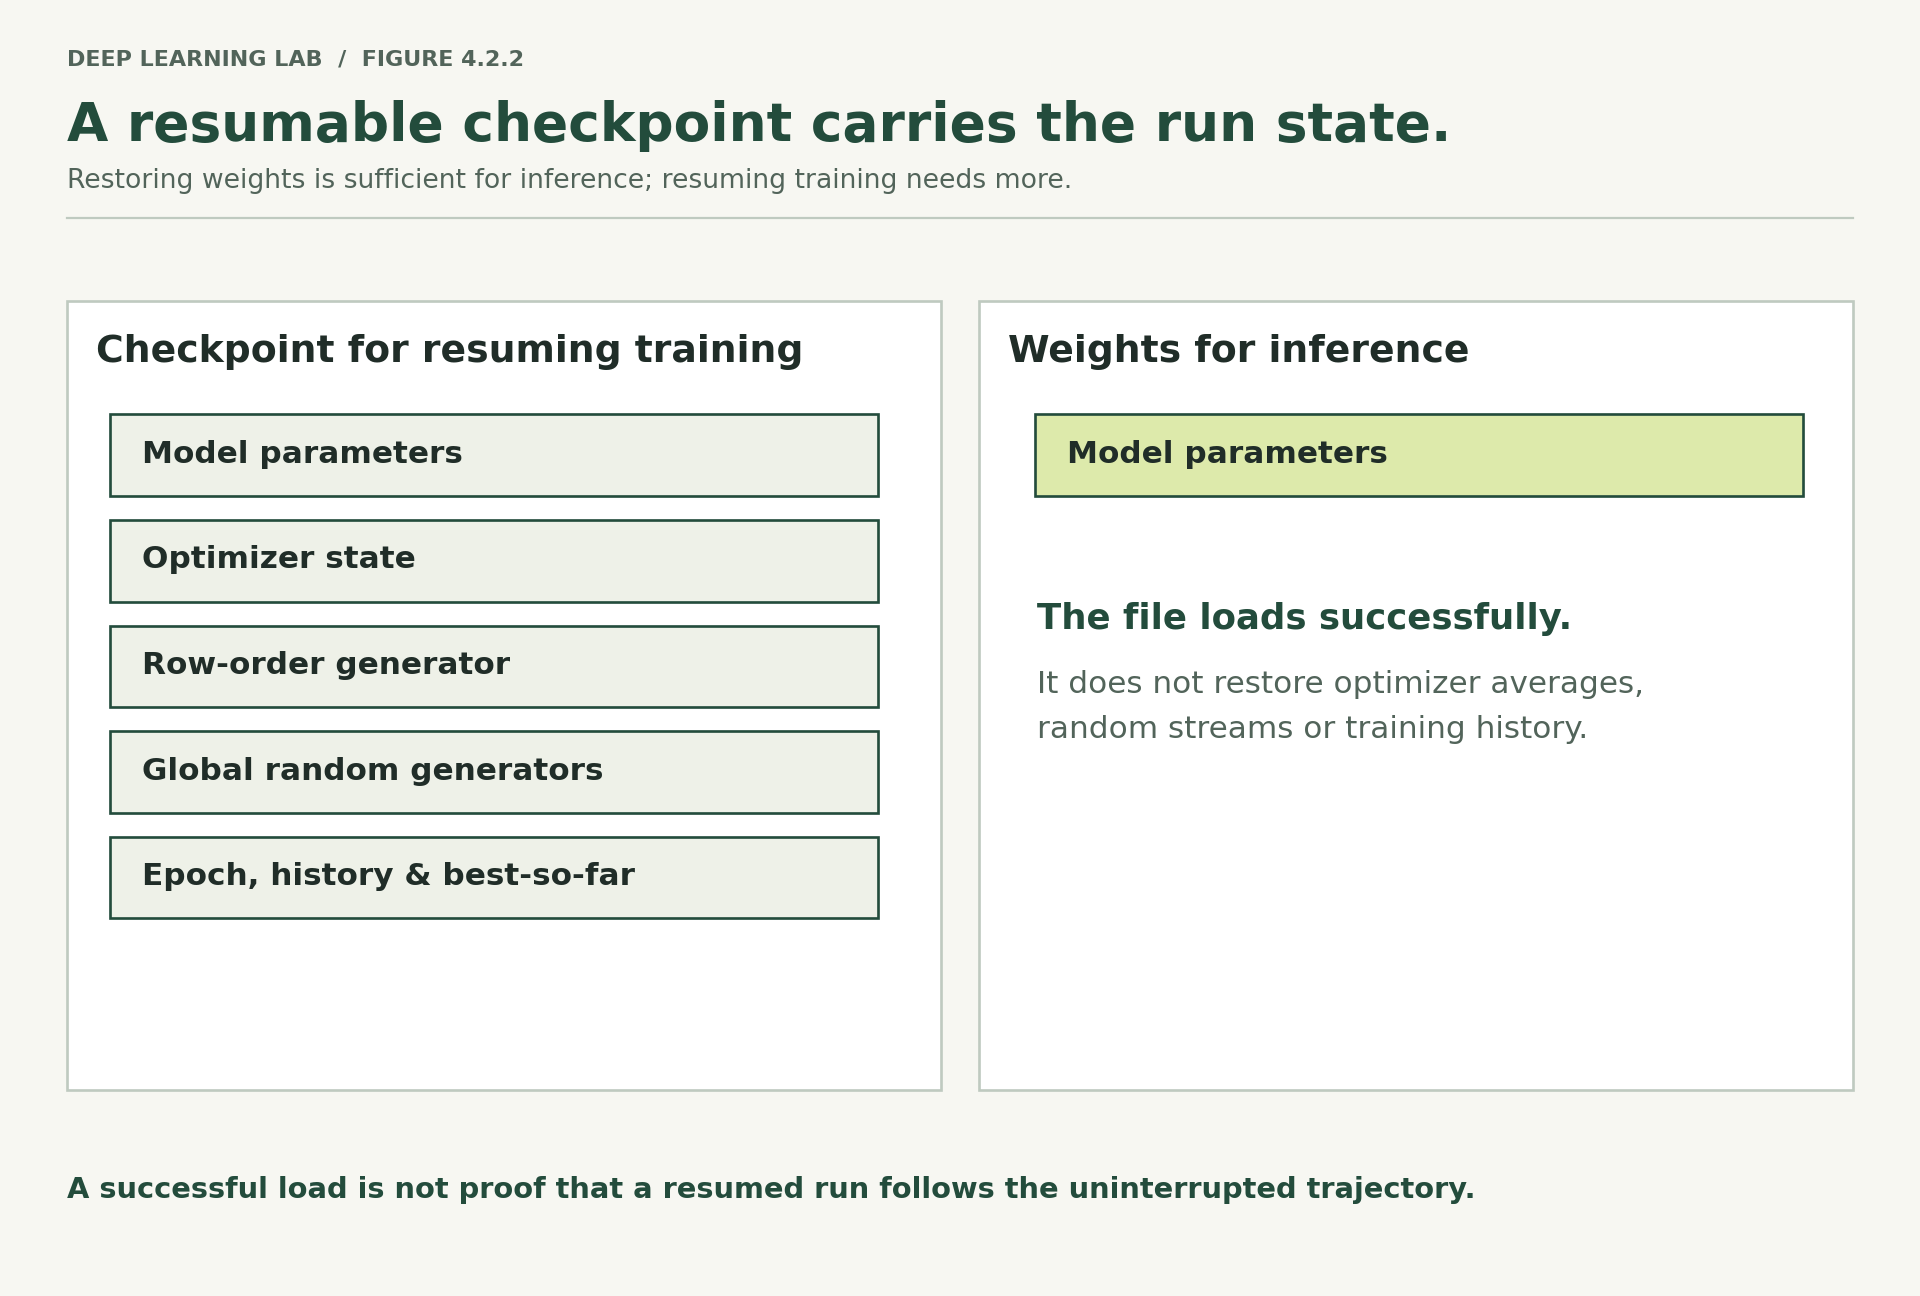

<p><b>Figure 4.2.2.</b> The state categories used by the lesson’s checkpoint. Matching software, hardware and deterministic operations also matter for repeatable continuation.</p>

</div>

**Questions to sit with**

1. List the five things a resumable checkpoint stores, and say what goes wrong if each is missing.
2. Why is `weights_only=True` the safer default for a file you downloaded?

<a id="s8"></a>
## 8. How much do two runs differ when nothing changed?

This is the most useful measurement in the note, and the one people skip.

Before you can say "this change improved the model by 0.005", you have to know how much the score moves **when you change nothing that matters**. If it moves by 0.01 on its own, your 0.005 is nothing.

Two different things can wobble, and it is worth separating them:

- **seed noise** — same rows, different starting weights and row order;
- **split noise** — same seed, different rows in training, validation and test.

Five runs of each. This takes about a minute and a half.

In [27]:
for value in range(5):
    run_experiment({"name": f"noise_seed{value}", "seed": value}, quiet=True)
    run_experiment({"name": f"noise_split{value}", "split_seed": value}, quiet=True)

rows = []
for value in range(5):
    for kind in ("seed", "split"):
        with open(f"results/noise_{kind}{value}.json") as f:
            saved_result = json.load(f)
        rows.append({"name": saved_result["settings"]["name"], "varies": kind,
                     "seed": saved_result["settings"]["seed"],
                     "split_seed": saved_result["settings"]["split_seed"],
                     "best_epoch": saved_result["best_epoch"],
                     "val_auc": saved_result["best_val_auc"],
                     "test_auc": saved_result["test"]["auc"],
                     "settings_hash": saved_result["run"]["settings_hash"],
                     "data": saved_result["run"]["data_fingerprint"]})

noise = pd.DataFrame(rows)
print(noise.round(4).to_string(index=False))
print()
print(noise.groupby("varies")[["val_auc", "test_auc"]].agg(["mean", "std"]).round(4).to_string())

        name varies  seed  split_seed  best_epoch  val_auc  test_auc settings_hash         data
 noise_seed0   seed     0          42          17   0.7853    0.8042  833b7bcd8923 ae4909e99a00
noise_split0  split    42           0          22   0.8118    0.7776  13381b2b509f ae4909e99a00
 noise_seed1   seed     1          42          21   0.7899    0.8047  91f50051d9d3 ae4909e99a00
noise_split1  split    42           1          18   0.7815    0.8098  086b696f29f9 ae4909e99a00
 noise_seed2   seed     2          42          18   0.7888    0.8031  05fef60116ca ae4909e99a00
noise_split2  split    42           2           8   0.8030    0.7850  5212cf0c316b ae4909e99a00
 noise_seed3   seed     3          42          17   0.7863    0.8055  f30399426058 ae4909e99a00
noise_split3  split    42           3          22   0.7894    0.7795  ca61cd8aaeae ae4909e99a00
 noise_seed4   seed     4          42          10   0.7856    0.8053  8dc0a9c4d0f4 ae4909e99a00
noise_split4  split    42           4   

The two are not the same size.

**Changing the seed moves test AUC by a standard deviation of 0.0010. Changing the split moves it by 0.0130** — about thirteen times as much. Validation AUC tells the same story: 0.0020 against 0.0123.

Standard deviation here just means "the typical distance from the average". So with a different split you should expect the score to land about 0.013 away from where it landed this time, in either direction, for no reason at all.

Three things follow.

**Almost all the uncertainty comes from which rows you tested on**, not from the starting weights. Rerunning with three seeds and averaging is nearly free reassurance that barely touches the number that actually moves.

**The average validation AUC (0.7948) is higher than the average test AUC (0.7885).** That is expected, not a bug. The best epoch was *chosen* by validation score, so validation is the best of 30 tries and carries that luck. Test chose nothing. Note 4.4 compares models on test only, for exactly this reason.

**The best epoch itself is noisy.** Look down that column: it ranges from 8 to 22 across the ten runs. The epoch that happened to be best is not a finding.

Finally, notice the last two columns. Every run has the same data fingerprint, because the file did not change. Every run has a different settings fingerprint, because seed and split seed are part of the settings.

**Questions to sit with**

1. Which of the two kinds of noise would shrink if you had ten times more data? Which might not?
2. If two models are compared on the *same* splits, which part of this noise cancels out? (Note 4.4 depends on the answer.)

<a id="s9"></a>
## 9. The experiment record

The numbers are saved. What is not saved is the thinking: why you ran it, what you concluded, what you would do next. Six months later that is the part you will wish you had.

Note 3.4 introduced this habit with five questions. Here they become a fixed format, so records can be skimmed and compared:

1. **What did I try?** — filled in automatically: which settings differ from the baseline.
2. **Why?** — your reason, written *before* you look at the result.
3. **What happened?** — filled in automatically from the result.
4. **What did I learn?** — your conclusion.
5. **What would I change next?** — the next experiment, so the record is also a plan.

The function refuses to write a record without a reason and a lesson, because a record without them is just the numbers again.

In [28]:
def experiment_record(result, why, learned, next_change, results_dir="results"):
    """Write results/<name>.md beside results/<name>.json. Returns the path."""
    if not why or not learned:
        raise ValueError("a record needs both a reason and a lesson")

    settings, run, test = result["settings"], result["run"], result["test"]
    ignore = {"name", "resume", "stop_after", "checkpoint_every"}
    changed = {k: v for k, v in settings.items()
               if k not in ignore and BASELINE.get(k) != v
               and not (isinstance(v, list) and list(BASELINE.get(k, [])) == v)}

    what_happened = (f"best validation AUC {result['best_val_auc']:.4f} at epoch {result['best_epoch']}; "
                     f"test AUC {test['auc']:.4f}, test PR-AUC {test['pr_auc']:.4f} "
                     f"(share who said yes {test['share_who_said_yes']:.3f}, "
                     f"average prediction {test['average_prediction']:.3f}); "
                     f"{result['seconds']:.1f} seconds")

    text = f"""### Experiment: {settings['name']}

run `{run.get('run_id', '?')}` · settings `{run.get('settings_hash', '?')}` · data `{run.get('data_fingerprint', '?')}` · commit `{run.get('git', {}).get('commit') or 'none'}` · torch {run.get('environment', {}).get('torch', '?')}

**1. What did I try?** Changed from the baseline: `{changed or 'nothing'}`

**2. Why?** {why}

**3. What happened?** {what_happened}

**4. What did I learn?** {learned}

**5. What would I change next?** {next_change}

Full history: `{results_dir}/{settings['name']}.json`
"""
    os.makedirs(results_dir, exist_ok=True)
    path = os.path.join(results_dir, f"{settings['name']}.md")
    with open(path, "w") as f:
        f.write(text)
    return path

path = experiment_record(
    weights_only_run,
    why="Resuming from a weights-only checkpoint should reproduce the uninterrupted run.",
    learned=("It does not. The optimizer's running averages and the row order restarted at epoch 13, "
             "and the final weights differ from the uninterrupted run."),
    next_change="Add the learning-rate schedule's state to the checkpoint once a schedule is in use.")
print(open(path).read())

### Experiment: weights_only

run `weights_only-1e51ebdd` · settings `175eba29a158` · data `ae4909e99a00` · commit `none` · torch 2.14.0+cpu

**1. What did I try?** Changed from the baseline: `nothing`

**2. Why?** Resuming from a weights-only checkpoint should reproduce the uninterrupted run.

**3. What happened?** best validation AUC 0.7866 at epoch 18; test AUC 0.7991, test PR-AUC 0.4629 (share who said yes 0.117, average prediction 0.118); 4.7 seconds

**4. What did I learn?** It does not. The optimizer's running averages and the row order restarted at epoch 13, and the final weights differ from the uninterrupted run.

**5. What would I change next?** Add the learning-rate schedule's state to the checkpoint once a schedule is in use.

Full history: `results/weights_only.json`



In [29]:
try:
    experiment_record(reference, why="", learned="", next_change="")
except ValueError as error:
    print("refused:", error)

refused: a record needs both a reason and a lesson


<a id="s10"></a>
## 10. The same runs in MLflow

What you have built — a run function, JSON results, Markdown records, fingerprints — is a complete tracking system, and you understand every part of it.

In a team, people usually use a ready-made tool instead of a folder of files, because it adds a searchable database, a web page for comparing runs, and a shared server everybody writes to. **MLflow** is a widely used open-source one. Here it runs on your own machine, storing everything in a single SQLite database file, with no account and no server to set up.

The run function does not change. A small function copies a saved result into MLflow.

The vocabulary MLflow uses:

- **parameters** — the settings, recorded once per run;
- **metrics** — numbers that can change as the run progresses, recorded with a `step` (our epoch);
- **tags** — short labels for searching, which is where the fingerprints go;
- **artifacts** — files attached to the run, such as our JSON and Markdown.

In [30]:
import logging
import mlflow

logging.getLogger("mlflow").setLevel(logging.ERROR)
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("day4-bank-marketing")

def log_to_mlflow(path):
    """Copy one saved result file into MLflow."""
    with open(path) as f:
        saved_result = json.load(f)
    settings, run = saved_result["settings"], saved_result["run"]

    with mlflow.start_run(run_name=settings["name"]):
        mlflow.log_params({key: str(value) for key, value in settings.items()})
        mlflow.set_tags({"settings_hash": run["settings_hash"],
                         "data_fingerprint": run["data_fingerprint"],
                         "torch": run["environment"]["torch"]})
        for row in saved_result["history"]:
            mlflow.log_metrics({"train_loss": row["train_loss"], "val_loss": row["val_loss"],
                                "val_auc": row["val_auc"]}, step=row["epoch"])
        mlflow.log_metrics({"best_val_auc": saved_result["best_val_auc"],
                            "test_auc": saved_result["test"]["auc"],
                            "best_epoch": saved_result["best_epoch"]})
        mlflow.log_artifact(path)

for file_name in sorted(f for f in os.listdir("results") if f.startswith("noise_") and f.endswith(".json")):
    log_to_mlflow(os.path.join("results", file_name))

runs = mlflow.search_runs(experiment_names=["day4-bank-marketing"], order_by=["metrics.test_auc DESC"])
print(runs[["tags.mlflow.runName", "metrics.best_val_auc", "metrics.test_auc",
            "metrics.best_epoch", "tags.settings_hash"]].round(4).to_string(index=False))

tags.mlflow.runName  metrics.best_val_auc  metrics.test_auc  metrics.best_epoch tags.settings_hash
       noise_split1                0.7815            0.8098                18.0       086b696f29f9
        noise_seed3                0.7863            0.8055                17.0       f30399426058
        noise_seed4                0.7856            0.8053                10.0       8dc0a9c4d0f4
        noise_seed1                0.7899            0.8047                21.0       91f50051d9d3
        noise_seed0                0.7853            0.8042                17.0       833b7bcd8923
        noise_seed2                0.7888            0.8031                18.0       05fef60116ca
       noise_split4                0.7882            0.7906                 9.0       9221e82929ef
       noise_split2                0.8030            0.7850                 8.0       5212cf0c316b
       noise_split3                0.7894            0.7795                22.0       ca61cd8aaeae
       noi

To browse the same runs in a web page, run this in a terminal from this folder and open the address it prints:

```
mlflow ui --backend-store-uri sqlite:///mlflow.db
```

What MLflow added: searching and sorting across runs, per-epoch curves you can lay on top of each other, and files kept with each run.

What it did not add: any of the discipline. The fingerprints, the commit, the reason and the lesson all still come from your own code and habits. A tracking tool will happily store a run from a folder full of uncommitted changes and tell you nothing is wrong.

**Questions to sit with**

1. MLflow stored the settings as text. What kind of comparison does that make awkward, and how would you fix it?
2. Name one thing your JSON-and-Markdown records give you that the MLflow logging above does not.

<a id="s11"></a>
## 11. Lab: reproduce a run from its record

The test of everything in this note: take a result file, and get its number again using nothing but the file.

In [31]:
with open("results/noise_split3.json") as f:
    old_result = json.load(f)

settings_from_file = {**old_result["settings"], "name": "noise_split3_reproduced"}
new_result = run_experiment(settings_from_file, quiet=True)

checks = {
    "same settings fingerprint": new_result["run"]["settings_hash"] == old_result["run"]["settings_hash"],
    "same data fingerprint": new_result["run"]["data_fingerprint"] == old_result["run"]["data_fingerprint"],
    "same software versions": {k: v for k, v in new_result["run"]["environment"].items() if k != "platform"}
                              == {k: v for k, v in old_result["run"]["environment"].items() if k != "platform"},
    "identical epoch-by-epoch history": new_result["history"] == old_result["history"],
    "identical test AUC": new_result["test"]["auc"] == old_result["test"]["auc"],
}
for label, passed in checks.items():
    print(f"  {label:<34} {passed}")

print(f"\n  recorded test AUC   {old_result['test']['auc']:.6f}")
print(f"  reproduced test AUC {new_result['test']['auc']:.6f}")

  same settings fingerprint          True
  same data fingerprint              True
  same software versions             True
  identical epoch-by-epoch history   True
  identical test AUC                 True

  recorded test AUC   0.779473
  reproduced test AUC 0.779473


All five pass, so that is a Level 1 reproduction from a file.

If you run this on a different machine, the first two checks should still pass, because settings and data are yours to control. The last two may not, if the software versions or the thread count differ — and the recorded environment block tells you exactly where to look. That is a Level 2 outcome, handled properly: not identical, and explained.

**Your turn.**

1. Write a settings file `configs/pos_weight.yaml` that sets `pos_weight: 7.5` (roughly the ratio of no answers to yes answers) and a new `name`.
2. Before running it, write down what you expect to happen to test AUC and to the average prediction. Note 4.1 Section 10 has the answer.
3. Load the file with `yaml.safe_load` and pass it to `run_experiment`.
4. Write the record with `experiment_record`, filling in all five questions.
5. Log it to MLflow with `log_to_mlflow` and compare it with `reference`.

In [32]:
# Scratch space for the lab.
# with open("configs/pos_weight.yaml", "w") as f:
#     yaml.safe_dump({"name": "pos_weight_7_5", "pos_weight": 7.5}, f)
# settings = yaml.safe_load(open("configs/pos_weight.yaml"))
# result = run_experiment(settings)
# experiment_record(result, why="...", learned="...", next_change="...")

print("results so far:", len([f for f in os.listdir("results") if f.endswith(".json")]), "JSON files,",
      len([f for f in os.listdir("results") if f.endswith(".md")]), "records")

results so far: 15 JSON files, 2 records


### What to take away

**"Reproducible" means three things.** Repeatable, to the last decimal. Portable, meaning close and explained. Robust, meaning the conclusion survives new seeds and splits. Test each one on purpose.

**Seed at the start of every run, and give the DataLoader its own generator.** One seed at the top of a notebook is not a repeatable run.

**Settings belong in a file**, identified by a fingerprint. And write `0.0003`, not `3e-4`.

**A checkpoint without the optimizer state is a weights file.** The full checkpoint reproduced the uninterrupted run exactly. The weights-only one did not, and said nothing.

**Every result carries its own provenance**: settings fingerprint, data fingerprint, commit and whether the folder was clean, and the software versions.

**Measure the noise before interpreting any difference.** Here the seed moves test AUC by 0.0010 and the split moves it by 0.0130. Anything smaller than that is not a result.

**Records answer five fixed questions**, two of which only you can answer. A tracking tool stores them. It does not make them true.

### Transition to Note 4.3

Every run in this note was small on purpose, so it could be repeated to the last decimal on any machine. Real models are not small, and the first wall people hit is memory: a message saying the GPU has run out of it.

Note 4.3 is about where that memory goes. How many bytes a model takes, why training needs about four times what the model itself does, why batch size is a memory decision as much as a training one, what fp16 and bf16 actually are, and what to do, in order, when the machine says it has run out.